# ARIM-Academy：　基礎編　Scikit-learn（予測）

## 本編の目標

本演習では、Bonton Housingをもとにして、日本の住宅価格を予測するための教材用データセットである**Japan Housingデータセット**を利用し、機械学習の基礎を習得します。このデータセットには、物件価格の中央値（bukken_kakaku_manen）をはじめ、犯罪率、部屋数、地域ごとの特性など、多岐にわたる特徴量が含まれています。

1. **データ前処理**  
実世界のデータ（Boston Housing）をベースであるため、欠損値や異常値が含まれている可能性があります。また、特徴量のスケールが異なる場合、モデルの学習に悪影響を与えることがあります。そこで、本演習では、欠損値の補完、異常値の検出・除去、標準化や正規化といったデータ前処理の手法を学びます。これにより、モデルの精度向上に繋がるデータの整形を行います。

2. **さまざまな回帰モデルの構築と比較**  
線形回帰、ランダムフォレストなど、代表的な回帰モデルを構築し、それぞれのモデルの予測性能を比較します。各モデルの特性を理解し、どのモデルが住宅価格を最も正確に予測できるかを実験的に検証します。

3. **モデル評価**  
構築したモデルの性能を評価するために、平均二乗誤差（MSE）や決定係数（R2スコア）などの評価指標を用います。これらの指標に基づいて、モデルの精度を定量的に評価し、より良いモデルへと改善するための指針を得ます。

4. **特徴量の重要度分析**  
モデルの学習過程で、各特徴量が予測にどの程度貢献しているのかを分析します。これにより、住宅価格に最も影響を与える要因を特定し、モデルの解釈性を高めることができます。また、特徴量選択の際に役立つ情報を得ることも可能です。

---

## データセット

<div style="border:1px solid #000; padding:10px;">

Japan Housingデータセットは、元のBoston Housing（1970年代の米国ボストン市の住宅データ）を日本の住宅事情に沿って変数名と単位を変換したARIMセミナー特化の教材用データセットです。元データと同じ統計的性質（多重共線性・ノイズ等）を保持しているため、scikit-learnを使った機械学習チュートリアルがそのまま適用できます。506件の地域データと13種類の特徴量が含まれています。

- **hanzairitu**: 該当地域の犯罪発生率（％）
- **teijyu_chiiki**: 低層住居専用地域などのゆったりした住宅地の割合
- **syogyo_wariai**: 商業・工業エリアが占める割合（％）
- **kawa_dummy**: 川沿い・リバービューのダミー変数（1=川に面する, 0=それ以外）
- **taiki_osen**: 大気汚染物質（NOx）の濃度指数
- **heyazu**: 1戸あたりの平均部屋数
- **furuya_wariai**: 築30年以上の古い建物の割合（％）
- **eki_toho_min**: 最寄りの中心駅・ターミナル駅までの徒歩時間（分）
- **kousoku_akusesu**: 主要幹線道路・高速道路インターへのアクセス利便性指数
- **koteishizan_zei**: 不動産の固定資産税評価額の税率インデックス
- **gakkyu_ninzu**: 地域の学校における教員1人あたりの生徒数（学級規模）
- **ryokuchi_wariai**: 街区における公園・緑地エリアの面積割合（％）
- **teishotoku_wariai**: 地域内の低所得世帯が占める割合（％）
- **bukken_kakaku_manen**: 物件価格（単位：万円）。通常はこの数値が目的変数として使われる

</div>

### 教材への接続
google colabにおけるオンラインの場合にこのラインを実行します。（<font color="red">Google colabに接続しない場合には不要</font>）

In [31]:
!git clone https://github.com/ARIM-Academy/Advanced_Tutorial_1.git
%cd Advanced_Tutorial_1

c:\Users\japan\Dropbox\ARIM\9_ARIM_Academy\Advanced_Tutorial_1_scikit-learn\Advanced_Tutorial_1


Cloning into 'Advanced_Tutorial_1'...


# 1.データセットの読み込みと前処理

### ライブラリのインポート
カリキュラムで扱うpythonのライブラリをimport文でロードします。 機械学習のライブラリであるscikit-learnは後半でimportします。

In [2]:
#ライブラリ
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib_fontja
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

### サンプルファイルの読み込み
pandasライブラリのread_csv()関数は、CSVファイルを読み込んでpandasのDataFrame形式に変換する関数です。ここでは、[data]フォルダ内に保存されているJapan_Housing.csvファイルをDataFrameとして読み込み、その結果をdfという変数に格納します。

In [3]:
#データセットの読み込み
df = pd.read_csv('data/Japan_Housing.csv')

In [ ]:
#データセットの確認
df

,hanzairitu,teijyu_chiiki,syogyo_wariai,kawa_dummy,taiki_osen,heyazu,furuya_wariai,eki_toho_min,kousoku_akusesu,koteishizan_zei,gakkyu_ninzu,ryokuchi_wariai,teishotoku_wariai,bukken_kakaku_manen
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,10.2,1,296,15.3,99.2,4.98,3600
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,12.4,2,242,17.8,99.2,9.14,3240
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,12.4,2,242,17.8,98.2,4.03,5205
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,15.2,3,222,18.7,98.7,2.94,5010
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,15.2,3,222,18.7,99.2,5.33,5430
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,6.2,1,273,21.0,98.0,9.67,3360
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,5.7,1,273,21.0,99.2,9.08,3090
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,5.4,1,273,21.0,99.2,5.64,3585
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,6.0,1,273,21.0,98.4,6.48,3300


# 2. データの探索的分析 (EDA)

探索的データ分析 (EDA) は、データに潜むパターンや特徴、関係性を視覚的に捉え、データに対する深い理解を得るための最初のステップです。EDAを通じて、データの品質を確認し、モデル構築に向けた準備を進めます。

### EDAの目的

EDAの主な目的は以下の通りです。

* **データの理解:** データセットの構造、変数の意味、データの分布などを把握します。
* **データの可視化:** グラフや図を用いて、データの分布、パターン、異常値などを視覚的に表現します。
* **変数間の関係性の探索:** 相関分析やクロス集計などを行い、変数間の関係性を明らかにします。
* **データの前処理への示唆:** 欠損値の処理、外れ値の検出、特徴量エンジニアリングで実施するデータ前処理への示唆を得ます。


### EDAの重要性
EDAは、データ分析の成功を左右する重要なステップです。EDAを通じて得られた知見は、以下の点に役立ちます。
* **適切なモデル選択:** データの特性に基づいて、最適な機械学習モデルを選択できます。
* **特徴量エンジニアリング:** 新しい特徴量を作成したり、既存の特徴量を加工したりすることで、モデルの性能を向上させることができます。
* **データの品質向上:** 欠損値や外れ値を検出し、適切な処理を行うことで、モデルの精度を向上させることができます。

### EDAの手法

EDAの手法は多岐にわたりますが、代表的な手法として以下が挙げられます。

#### 2.1 概要統計量の算出
* **目的:** データの全体的な傾向を把握します。
* **手法:** 平均値、中央値、標準偏差、最小値、最大値などを計算します。
* **ツール:** pandasの`describe()`メソッドなど

#### 2.2 ペアプロットと相関係数の計算
* **目的:** 数値型変数間の関係性を可視化し、相関関係を定量的に評価します。
* **手法:** 散布図行列を作成し、各変数間の相関係数を計算します。
* **ツール:** seabornの`pairplot()`関数、pandasの`corr()`メソッドなど

#### 2.3 データの可視化
* **目的:** データの分布、パターン、異常値などを視覚的に捉えます。
* **手法:** ヒストグラム、箱ひげ図、散布図、バイオリンプロットなど
* **ツール:** matplotlib、seabornなど

#### 2.4 相関係数のヒートマップ
* **目的:** 相関係数行列を色で表現し、変数間の関係性を直感的に把握します。
* **手法:** 相関行列をヒートマップとして可視化します。
* **ツール:** seabornの`heatmap()`関数など


4つそれぞれのデータ分析についてみてみましょう

### ①概要統計
概要統計（Descriptive Statistics）は、データセットの要約統計量を計算することで、データの特徴や分布を理解する手法です。出力される指標は、平均、中央値、最小値、最大値、標準偏差、四分位数です。

pandasライブラリに含まれている`describe()`メソッドを使うとデータセットの概要統計を簡単に取得することができます。
具体的には、`describe()`メソッドは以下の統計情報を計算します：

1. **カウント（Count）:** データの非欠損値の数を示します。
2. **平均（Mean）:** データの平均値を示します。
3. **標準偏差（Standard Deviation）:** データのばらつきの尺度を示します。
4. **最小値（Minimum）:** データの最小値を示します。
5. **第一四分位数（25th Percentile）:** データの下位25%の境界値を示します。
6. **中央値（Median）:** データの中央値（50thパーセンタイル）を示します。
7. **第三四分位数（75th Percentile）:** データの下位75%の境界値（上位25%との境界）を示します。
8. **最大値（Maximum）:** データの最大値を示します。

In [4]:
#概要統計
df.describe()

,hanzairitu,teijyu_chiiki,syogyo_wariai,kawa_dummy,taiki_osen,heyazu,furuya_wariai,eki_toho_min,kousoku_akusesu,koteishizan_zei,gakkyu_ninzu,ryokuchi_wariai,teishotoku_wariai,bukken_kakaku_manen
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,9.488933,9.549407,408.237154,18.455534,89.162451,12.653063,3379.920949
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,5.264474,8.707259,168.537116,2.164946,22.820467,7.141062,1379.565613
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,2.800000,1.000000,187.000000,12.600000,0.100000,1.730000,750.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,5.225000,4.000000,279.000000,17.400000,93.825000,6.950000,2553.750000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,8.000000,5.000000,330.000000,19.050000,97.900000,11.360000,3180.000000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,12.950000,24.000000,666.000000,20.200000,99.100000,16.955000,3750.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,30.300000,24.000000,711.000000,22.000000,99.200000,37.970000,7500.000000


### ②　ペアプロット（散布図行列）
ペアプロット（Pair plot）は、データセット内の複数の数値変数の組み合わせに基づいた散布図行列を可視化する手法です。これにより、変数間の相関やパターンを把握することができます。

ペアプロットを作成するライブラリは幾つかありますが、Seabornライブラリの`pairplot()`メソッドは比較的に簡単にデータセット内の数値変数の組み合わせに基づいて散布図行列を作成し、各変数間の散布図やヒストグラムを表示します。

`pairplot()`メソッドには、さまざまなオプションを持ちます。たとえば、`hue`パラメータを使用すると、カテゴリ変数に基づいて散布図の色分けが行えます。また、`diag_kind`パラメータを使用すると、対角線上に表示されるヒストグラムやカーネル密度推定プロットの種類を指定することもできます。

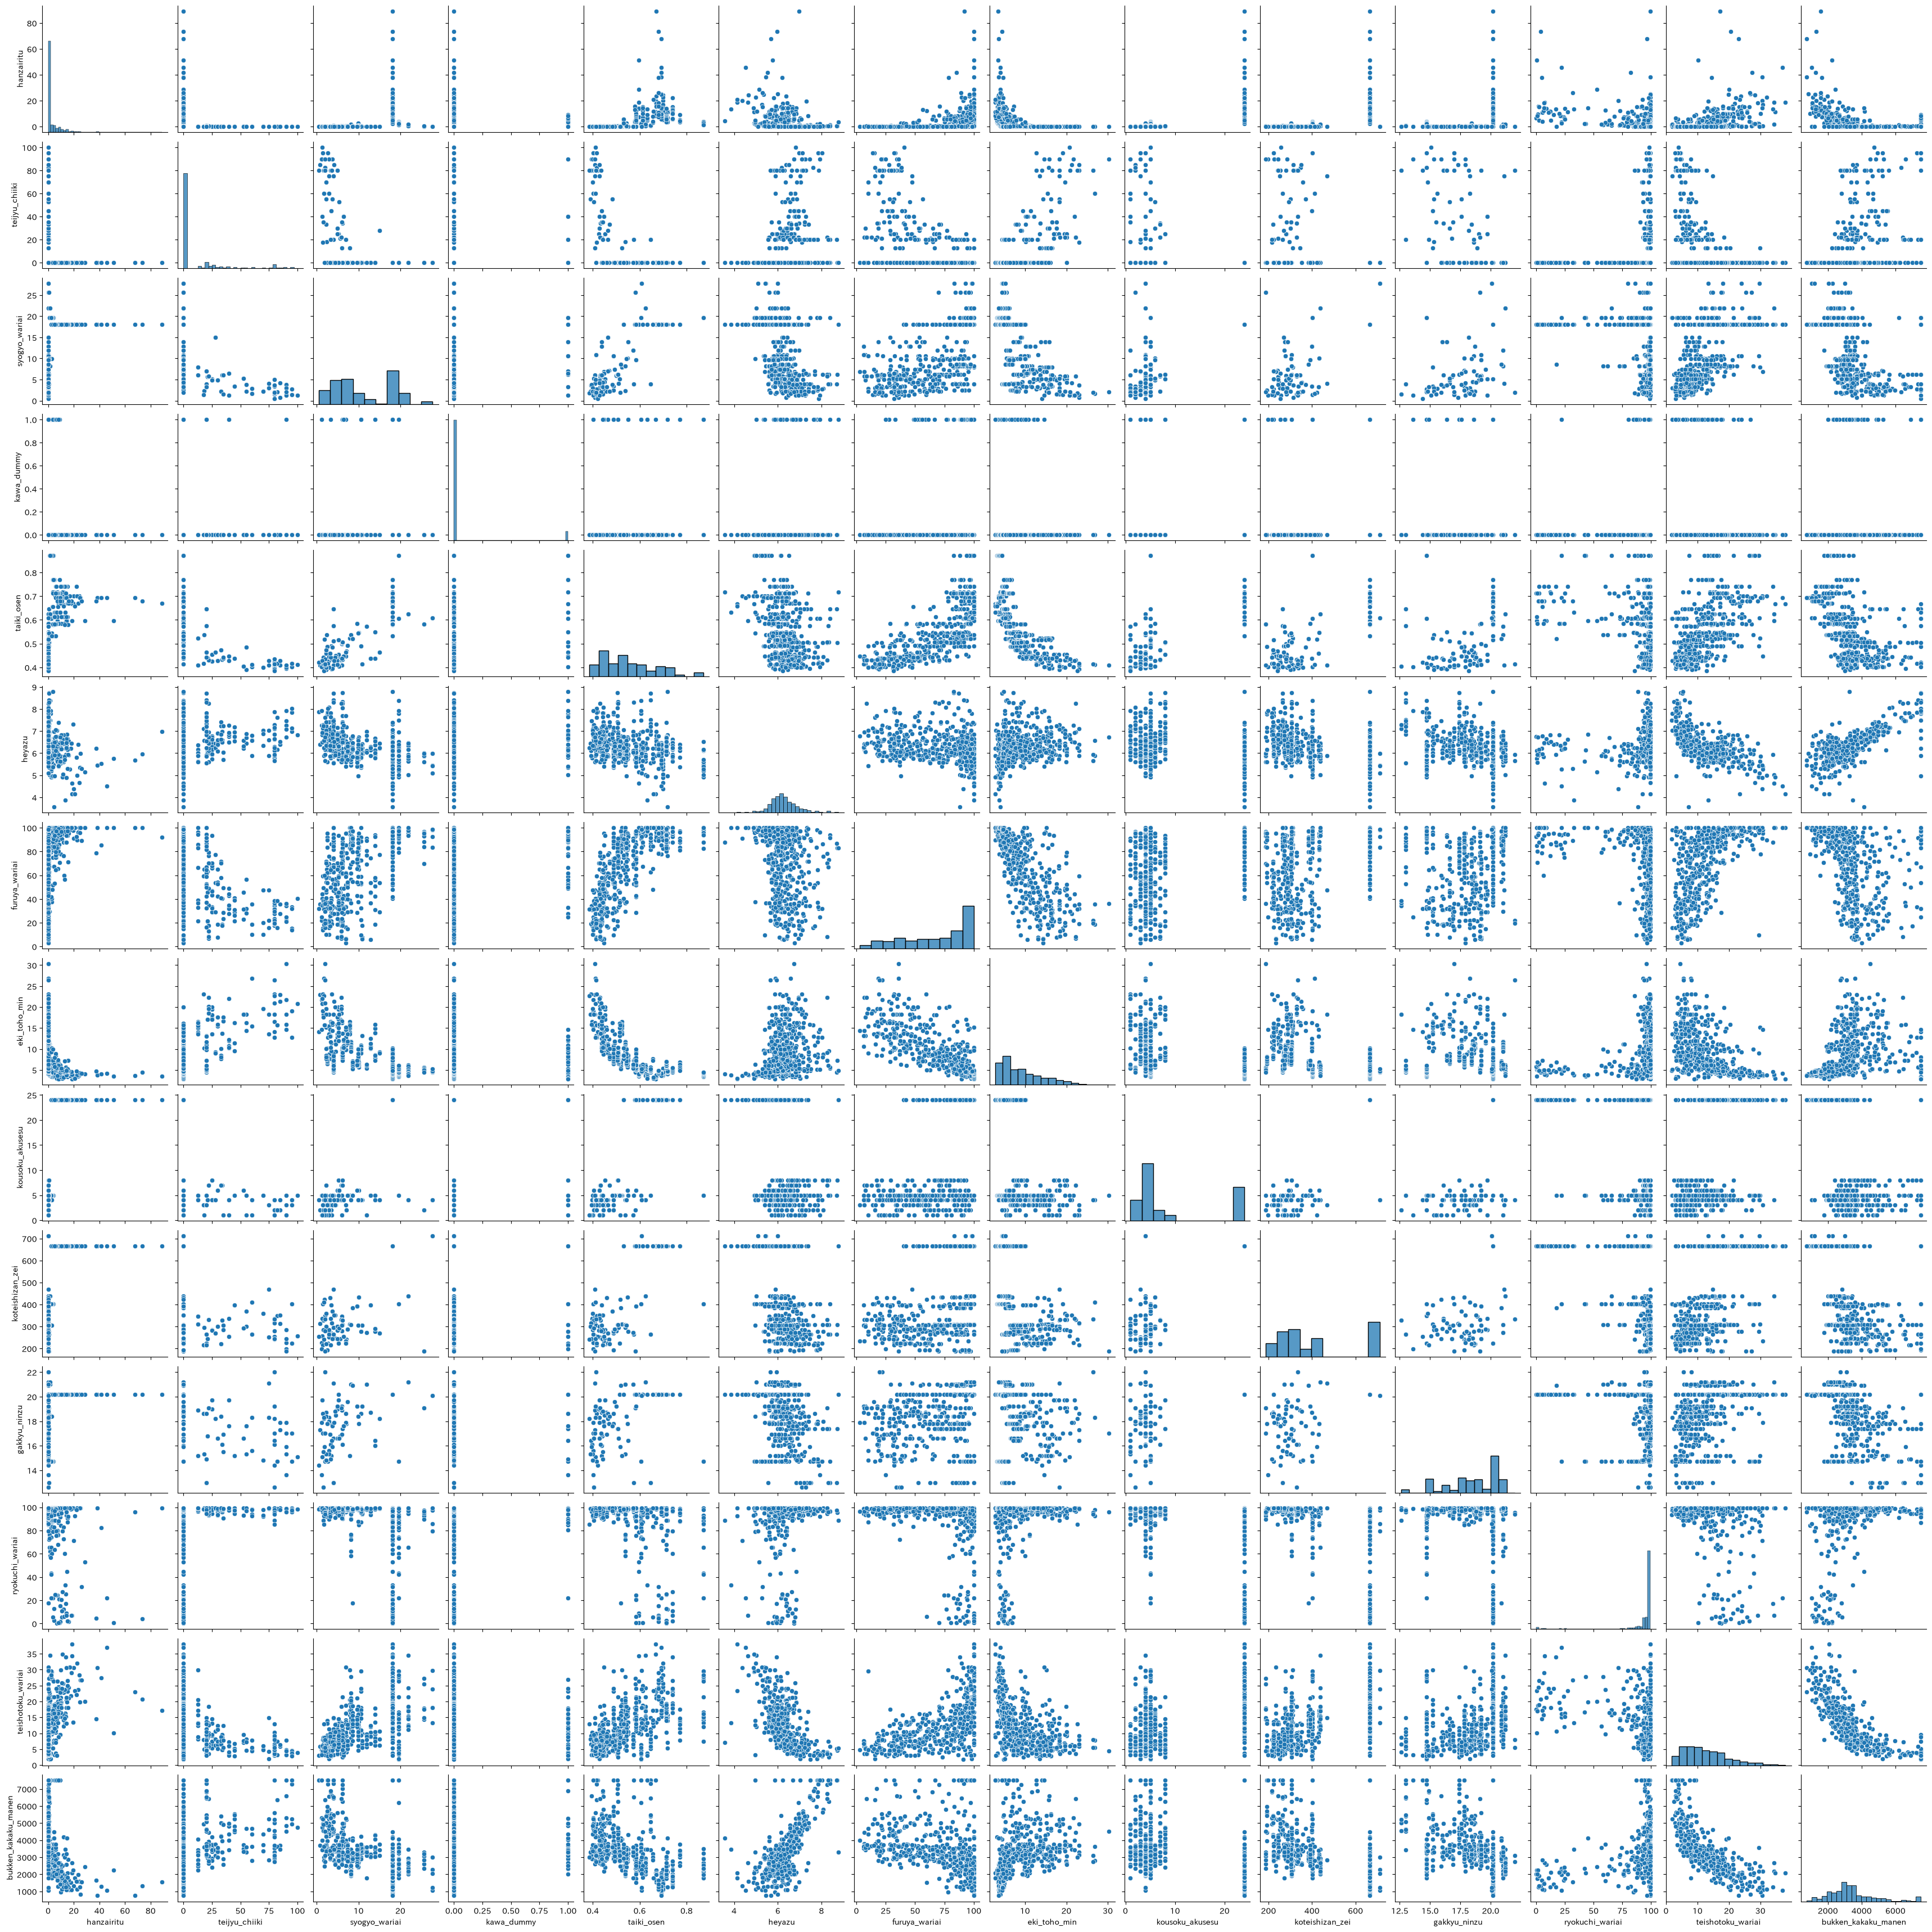

In [5]:
#　ペアプロットによる各変数間の二次元空間像
sns.pairplot(df)
plt.show()

表示させる変数名を絞り込んでみましょう。`pairplot()`のメソッドでは次のようにデータフレームの変数名を指定することで対応できます。

> **注意:** 以下のコードでは変数名に `TARGET` を使っていますが、慣習的に `TARGET` は目的変数（住宅価格など）を指す名前です。ここでは可視化対象の**特徴量**リストなので、`FEATURES` や `COLS` などの名前を使う方が誤解を招きません。

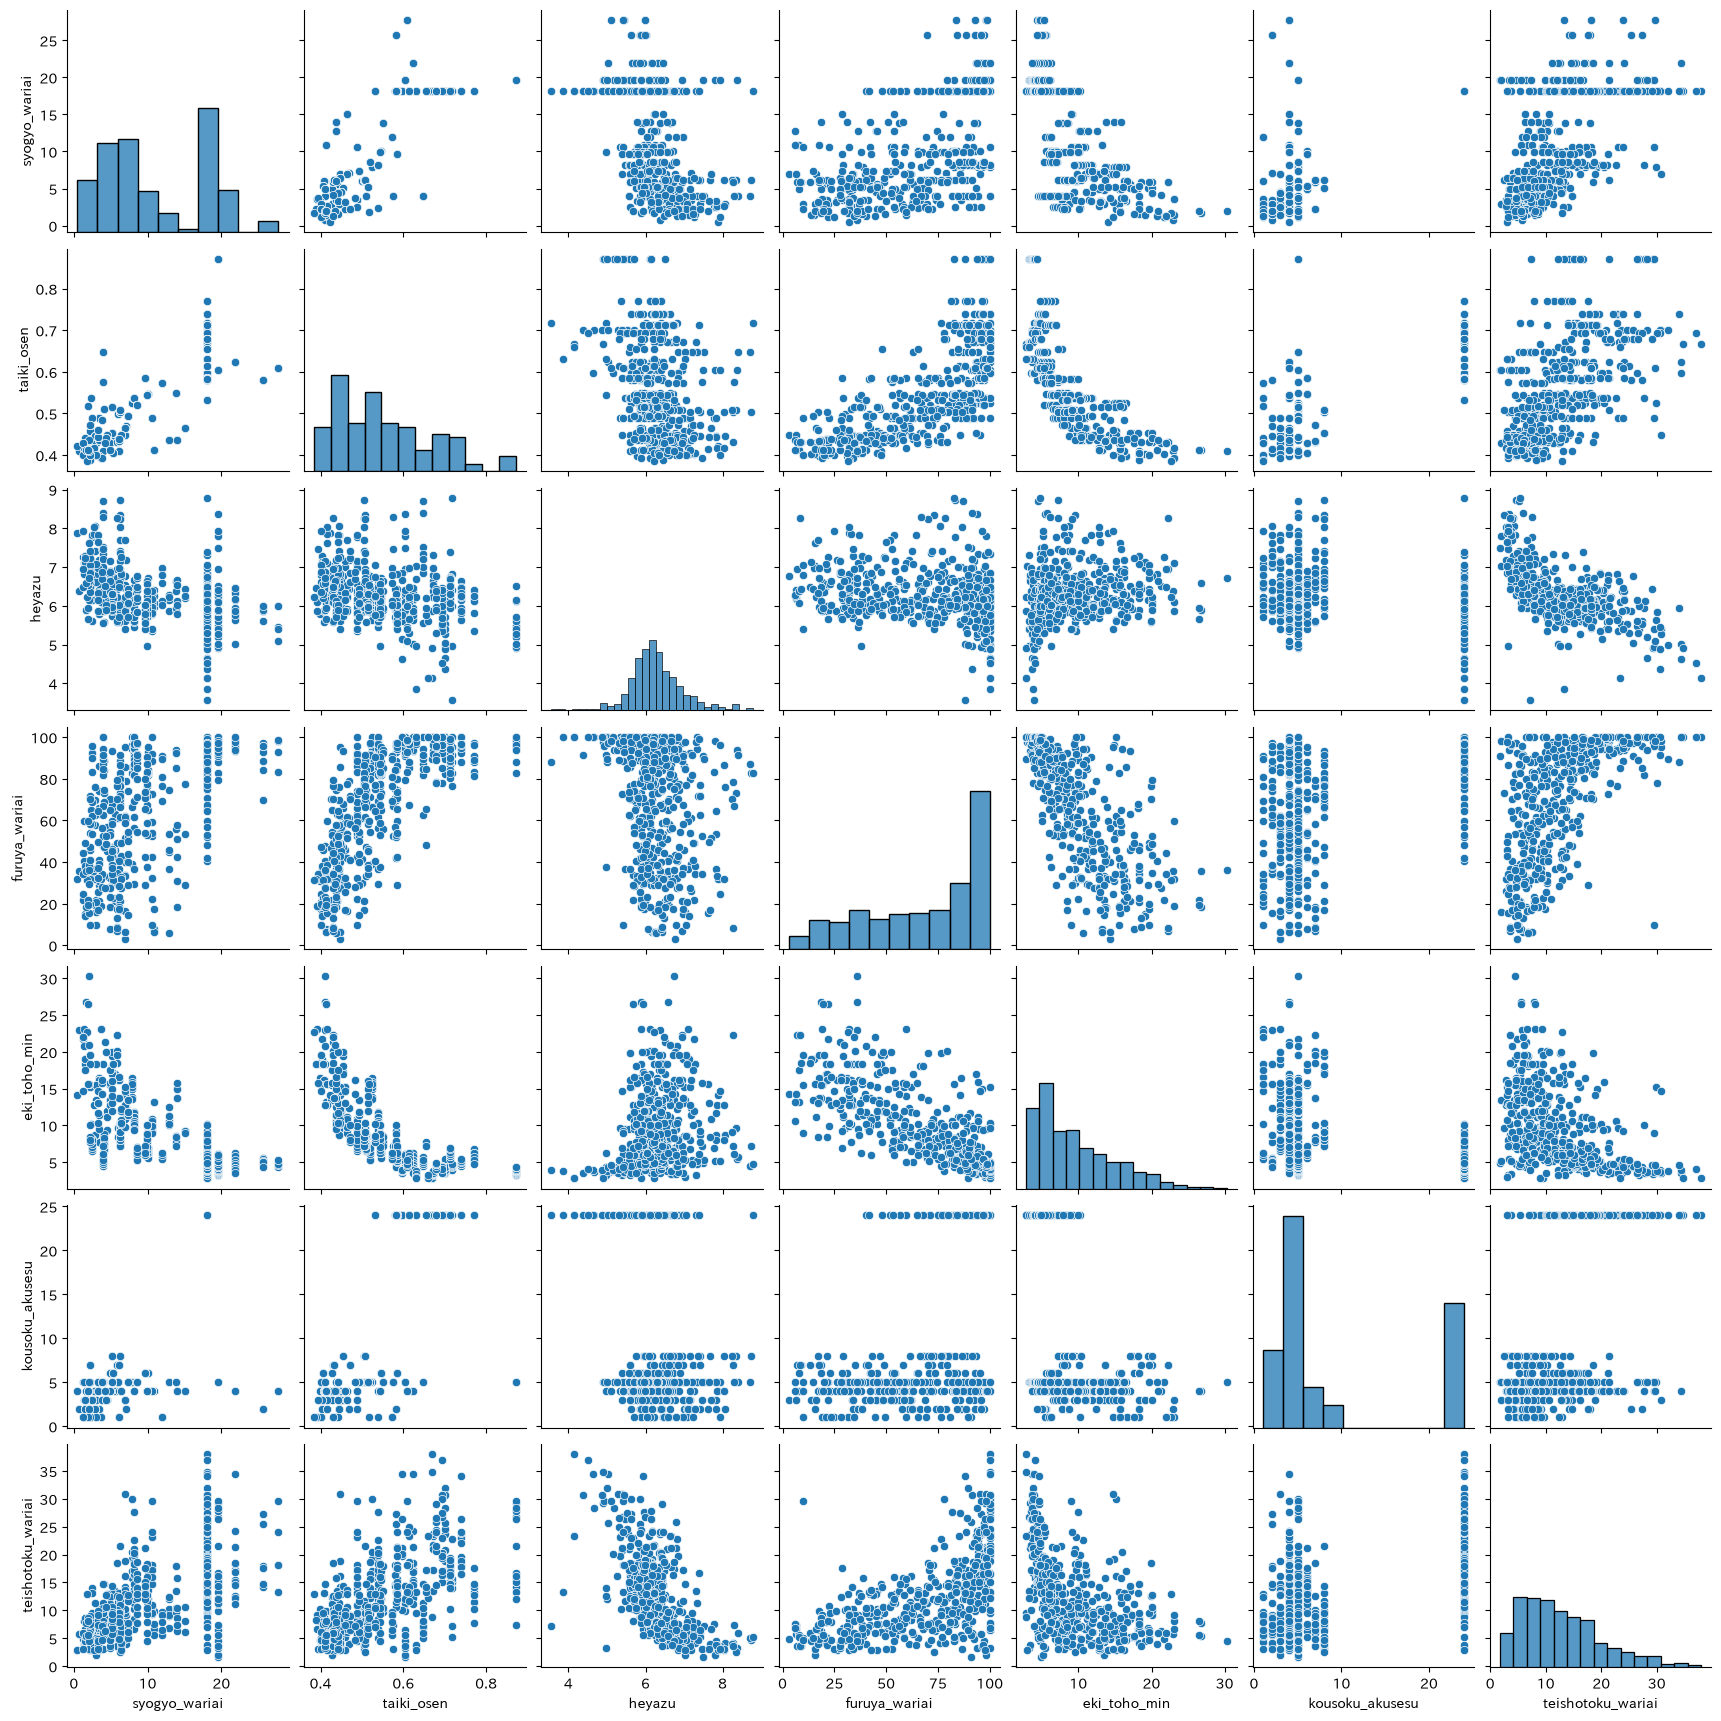

In [6]:
#　ペアプロットによる各変数間の二次元空間像（その２）
TARGET=['syogyo_wariai','taiki_osen','heyazu','furuya_wariai','eki_toho_min','kousoku_akusesu','teishotoku_wariai']
sns.pairplot(df[TARGET])
plt.show()

### ③ピアソン相関係数

ピアソンの相関係数は、2つの変数の間の線形関係の強さと方向を示す統計的指標です。値は-1から1の範囲を取り、以下のように解釈されます：

1：完全な正の相関（変数が同じ方向に変動）  
0：相関なし（変数間に線形関係がない）  
-1：完全な負の相関（変数が逆の方向に変動）  

相関係数の絶対値が大きいほど、2つの変数間の線形関係が強いことを示します。

pandasの`corr()`メソッドを使用すると数値データを持つ全ての列間の相関係数を計算し、相関行列として出力します。

In [7]:
#　相関係数
corr = df.corr()
corr

,hanzairitu,teijyu_chiiki,syogyo_wariai,kawa_dummy,taiki_osen,heyazu,furuya_wariai,eki_toho_min,kousoku_akusesu,koteishizan_zei,gakkyu_ninzu,ryokuchi_wariai,teishotoku_wariai,bukken_kakaku_manen
hanzairitu,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379643,0.625505,0.582764,0.289946,-0.385152,0.455621,-0.388305
teijyu_chiiki,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664537,-0.311948,-0.314563,-0.391679,0.175523,-0.412995,0.360445
syogyo_wariai,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.707609,0.595129,0.720760,0.383248,-0.356984,0.603800,-0.483725
kawa_dummy,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.098944,-0.007368,-0.035587,-0.121515,0.048756,-0.053929,0.175260
taiki_osen,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769056,0.611441,0.668023,0.188933,-0.380028,0.590879,-0.427321
heyazu,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.204833,-0.209847,-0.292048,-0.355501,0.128087,-0.613808,0.695360
furuya_wariai,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747709,0.456022,0.506456,0.261515,-0.273538,0.602339,-0.376955
eki_toho_min,-0.379643,0.664537,-0.707609,-0.098944,-0.769056,0.204833,-0.747709,1.000000,-0.494433,-0.534102,-0.232483,0.291404,-0.496604,0.249393
kousoku_akusesu,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494433,1.000000,0.910228,0.464741,-0.444415,0.488676,-0.381626
koteishizan_zei,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534102,0.910228,1.000000,0.460853,-0.441811,0.543993,-0.468536


### ④相関係数のヒートマップ
相関係数の数値だけでは、変数間の関係を直感的に捉えづらいことがあります。そこで、ヒートマップを用いて相関係数行列を可視化することで、変数間の関係性を視覚的に把握します。  

seabornライブラリのheatmap()関数は、DataFrame内の数値データの相関係数を色で表現したヒートマップを簡単に作成できます。さらに、annot=Trueオプションを指定することで、各セルに相関係数の数値を表示し、より詳細な情報を得ることができます。

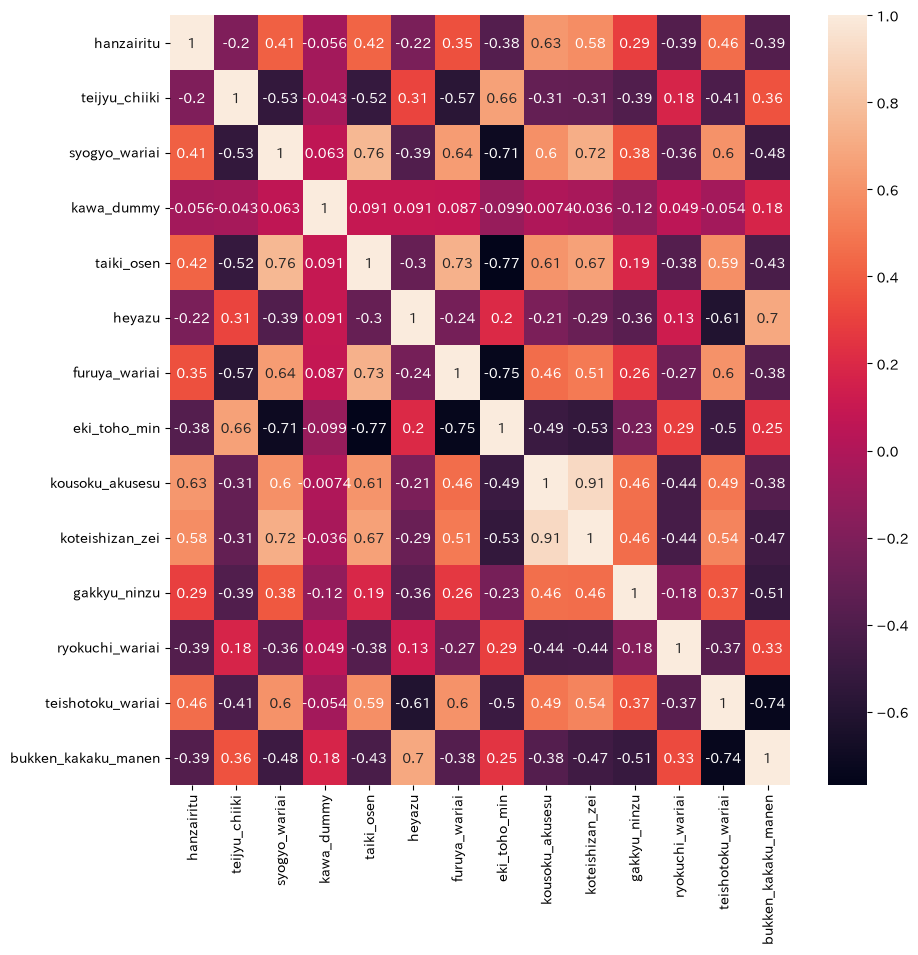

In [8]:
#相関係数をヒートマップ化する

plt.figure(figsize=(10,10))

sns.heatmap(corr, annot=True)
plt.show()

# 3.着目する特徴量の可視化
ペアプロットでは対象とするすべての相関グラフとヒストグラムを出力しました。ここでは、特に着目する特徴量のグラフについてmatpltlibを使って描画する流れを学びます。

### 頻度分析（ヒストグラム）
Japan Housingデータセットにおける物件価格（万円）の分布を視覚化するヒストグラムを表示し、価格帯ごとの頻度をみてみましょう。

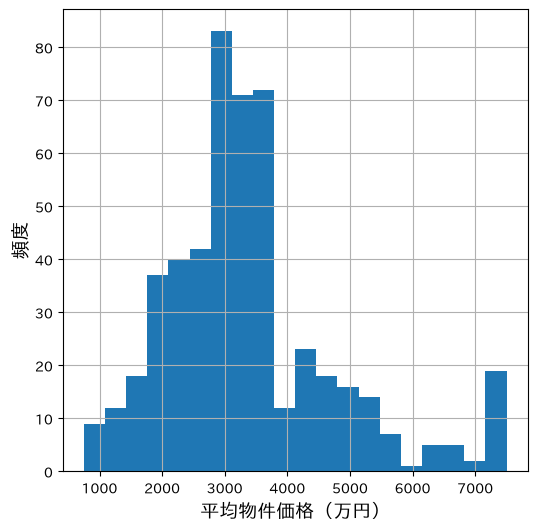

In [9]:
# 物件価格のヒストグラム
fig, ax = plt.subplots(figsize=(6,6))

#着目する変数の指定（ここでは物件価格）
X = df['bukken_kakaku_manen']

#ビン数は20分割
ax.hist(X, bins = 20)

#ラベル名
plt.xlabel('平均物件価格（万円）', fontsize=14)
plt.ylabel('頻度', fontsize =14)

plt.grid()
plt.show()

### 相関図
Japan Housingデータセットを使って、平均物件価格（bukken_kakaku_manen）と部屋数（heyazu）との関係を示す散布図を作成してみましょう。

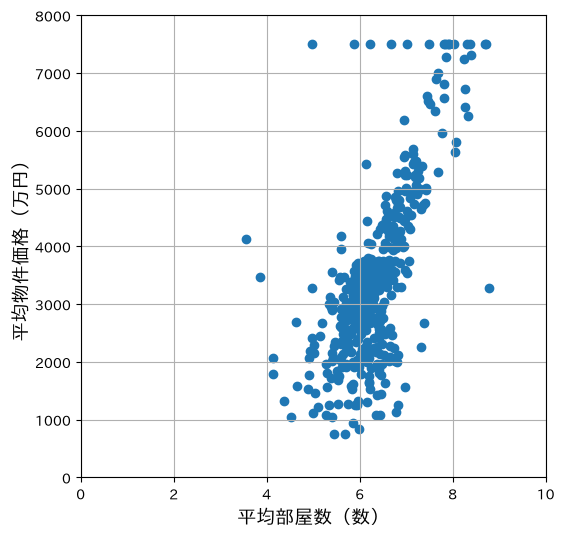

In [10]:
#平均物件価格と部屋数との相関図
fig, ax = plt.subplots(figsize=(6,6))

#着目する変数の指定（ここでは物件価格と部屋数）
X = df[['heyazu']]
y = df[['bukken_kakaku_manen']]

ax.scatter(X,y)

plt.xlabel("平均部屋数（数）", fontsize =14)
plt.ylabel("平均物件価格（万円）", fontsize =14)

plt.xlim(0, 10)
plt.ylim(0, 8000)

plt.grid()
plt.show()

### 特定の数値のフィルタリング
Japan Housingデータセットでは、平均物件価格（bukken_kakaku_manen）の上限が7,500万円に設定されており、実際の価格が7,500万円を超える物件はすべて7,500万円と記録されています。このため、**データの分布が歪んでいる可能性**があります。特に高価格帯の物件を分析する際には、この上限値の影響を考慮する必要があります。

《データ作業》そこで、ここでは7,500万円以上の価格のデータを除外し、分析を進めることにします。

In [12]:
#平均物件価格と部屋数との相関図

# 7500万円以上の価格のデータを除外
filtered_df = df[df['bukken_kakaku_manen'] < 7500]
filtered_df

,hanzairitu,teijyu_chiiki,syogyo_wariai,kawa_dummy,taiki_osen,heyazu,furuya_wariai,eki_toho_min,kousoku_akusesu,koteishizan_zei,gakkyu_ninzu,ryokuchi_wariai,teishotoku_wariai,bukken_kakaku_manen
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,10.2,1,296,15.3,99.2,4.98,3600
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,12.4,2,242,17.8,99.2,9.14,3240
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,12.4,2,242,17.8,98.2,4.03,5205
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,15.2,3,222,18.7,98.7,2.94,5010
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,15.2,3,222,18.7,99.2,5.33,5430
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,6.2,1,273,21.0,98.0,9.67,3360
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,5.7,1,273,21.0,99.2,9.08,3090
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,5.4,1,273,21.0,99.2,5.64,3585
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,6.0,1,273,21.0,98.4,6.48,3300


In [13]:
# フィルタリングされたデータの取得
X = filtered_df[['heyazu']]
y = filtered_df[['bukken_kakaku_manen']]

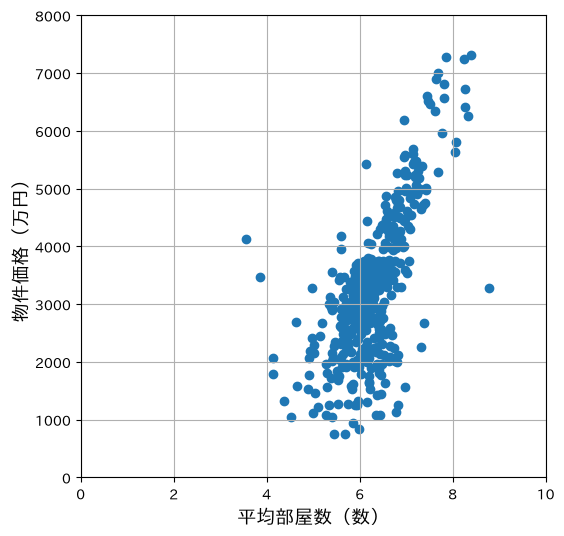

In [14]:
#平均物件価格（フィルタ後）と部屋数との相関図

fig, ax = plt.subplots(figsize=(6,6))

ax.scatter(X,y)

plt.xlabel("平均部屋数（数）", fontsize =14)
plt.ylabel("物件価格（万円）", fontsize =14)

plt.xlim(0, 10)
plt.ylim(0, 8000)

plt.grid()
plt.show()

### Scikit-Learnに慣れる：　単回帰モデル
線形回帰モデルは、複数の入力変数（特徴量）と一つの出力変数（目的変数）の間の関係を、直線または平面（多次元の場合）で表すモデルです。つまり、入力変数の値が変化すると、出力変数の値が線形に変化するという仮定に基づいています。　　

この中で、最もシンプルなモデルが「単回帰」です。単回帰は、一つの入力変数と一つの出力変数の間の関係を直線で表すモデルです。

《データ作業》Pythonの機械学習ライブラリであるscikit-learnを用いて、部屋数（数）から平均物件価格（bukken_kakaku_manen）を予測する単回帰分析を行う方法を解説します。

#### ①変数の指定
scikit-learnでは、説明変数 `X` は2次元の配列（DataFrame）として渡す必要があります。二重括弧 `[[列名]]` を使うとDataFrame（2次元）になります。一方、目的変数 `y` は1次元の配列（Series）として渡すのが標準です。一重括弧 `[列名]` を使うとSeries（1次元）になります。

In [16]:
# フィルタリングされたデータの取得
X = filtered_df[['heyazu']]          # 2次元DataFrame（scikit-learnはXに2次元を要求）
y = filtered_df['bukken_kakaku_manen']  # 1次元Series（yは1次元が標準）

#### ②機械学習モデル作成（とても重要）
以下のように
* （１）ライブラリのimport
* （２）予測器の作成
* （３）モデルの訓練（Fittingとも称される）

の3行で実質的な機械学習モデルの構築とトレーニングが完了します。


In [17]:
# 線形回帰モデル
from sklearn.linear_model import LinearRegression

#予測器の作成
model = LinearRegression()

#モデルの訓練（フィッティング）
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[1240.28]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['heyazu']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-4501
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


【解説】  
[1] **ライブラリのインポート**:  
ここではScikit-learnライブラリのlinear_modelモジュールから線形回帰モデルのためのクラスである`LinearRegression`クラスをインポートします。  

[2] **機械学習モデルの設定（インスタンス化）**：  
Scikit-learnで機械学習モデルを行う場合、まず機械学習モデルのクラスをインスタンス化します。上記では線形回帰モデルを適用するので、線形回帰モデルのクラスである`LinearRegression()`をmodel（インスタンス変数）として指定して、インスタンスを作成しています。

[3] **モデルの訓練（Fitting）**：  
続いてインスタンスに`fit()`メソッドを作用させて、与えられたデータに基づいて、入力変数と出力変数の関係を最もよく説明する線形関数の係数を計算し、フィッティングします。これは機械学習では訓練（Training）と称されます。

#### ③予測値の計算
訓練済みの線形回帰モデルを使用して、入力データXに基づいて予測値を計算する方法は、`predict()`メソッドを使います。以下の例では`model.predict(X)`の結果は、入力データに対する予測された出力変数（目的変数）の値であり、`y_pred`という変数に格納されます。

In [ ]:
y_pred = model.predict(X)

#### ⑤予測値の可視化
データに対して④で予測された値（予測値）を布置し、実際の価格と予測された価格をプロットします。

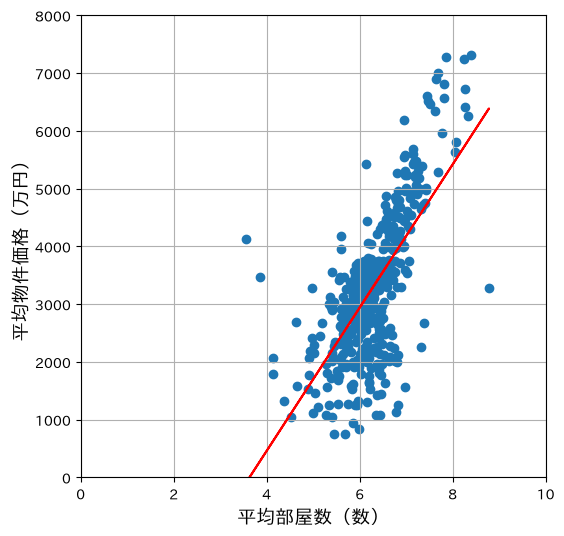

In [ ]:
#物件価格と部屋数との関係図（単回帰）
fig, ax = plt.subplots(figsize=(6,6))

ax.scatter(X, y)
ax.plot(X, y_pred, linestyle="solid", color = "red")

plt.xlabel("平均部屋数（数）", fontsize =14)
plt.ylabel("平均物件価格（万円）", fontsize =14)

plt.xlim(0, 10)
plt.ylim(0, 8000)

plt.grid()
plt.show()

In [34]:
print('①　係数：', model.coef_[0])
print('②　切片：',model.intercept_)

①　係数： 1240.2835983640473
②　切片： -4500.768021806378


【解説】  
① **係数**： `model.coef_` は線形回帰モデルの係数（回帰係数）を表します。この場合、`model.coef_[0]` は、最初の特徴量の係数を表示します。もし複数の特徴量がある場合は、`model.coef_` は配列で、各要素が対応する特徴量の係数になります。

② **切片**： `model.intercept_` は線形回帰モデルの切片（回帰直線がY軸と交わる点の値）を表示します。これは、すべての特徴量がゼロの場合の予測値です。

#### ⑥モデルの評価
モデルの性能を評価するために、いくつかの指標を用います。代表的な指標として、　　
* 平均二乗誤差（MSE）
* 平均絶対誤差（MAE）
* 決定係数（R²スコア）

などが挙げられます。

今回は、決定係数と相関係数に注目してモデルを評価します。
* 決定係数: モデルが実際のデータの変動をどれくらい説明できているかを示す指標
* 相関係数: 予測値と実際の値の間の線形な関係の強さを表す指標

決定係数は、一般的に0から1の値をとり、1に近いほどモデルの当てはまりが良いことを示します。また、相関係数は-1から1の値をとり、1に近ければ強い正の相関、-1に近ければ強い負の相関、0に近ければ相関がないことを示します。

In [35]:
print('③　決定係数 R^2： {:.3f}'.format(model.score(X, y)))

# 相関係数を予測値と実測値から直接計算（符号を保持するため）
y_pred_all = model.predict(X)
correlation_coefficient = np.corrcoef(y.values.flatten(), y_pred_all.flatten())[0, 1]
print('④　相関係数： {:.3f}'.format(correlation_coefficient))

③　決定係数 R^2： 0.471
④　相関係数： 0.687


【解説】  
① **決定係数**： `model.score(X, y)` はモデルの決定係数 \( R^2 \) を計算します。決定係数 \( R^2 \) は、モデルがどれだけデータの分散を説明できるかを示す指標で、1に近いほどモデルの説明力が高いことを意味します。決定係数の定義式は以下の通りです：

$$
R^2 = 1 - \frac{\text{RSS}}{\text{TSS}}
$$

ここで、RSS（残差平方和）はモデルの予測と実際の値の差の平方和、TSS（全平方和）は実際の値とその平均値との差の平方和です。`{:.3f}` は、出力を小数点以下3桁にフォーマットして表示するための指定です。

② **相関係数**： 相関係数は、実際の値と予測値との線形関係の強さと**方向**を示す指標です。値は −1 から 1 の範囲をとり、正の値なら正の相関、負の値なら負の相関を意味します。

$$
r = \frac{\sum (y_i - \bar{y})(\hat{y}_i - \bar{\hat{y}})}{\sqrt{\sum (y_i - \bar{y})^2} \cdot \sqrt{\sum (\hat{y}_i - \bar{\hat{y}})^2}}
$$

ここで、`np.corrcoef(y, y_pred)[0, 1]` を使って実測値と予測値の組から直接計算します。  
注意：単純回帰では $r^2 = R^2$ が成り立ちますが、$r = \sqrt{R^2}$ とすると**符号の情報が失われる**ため、`np.corrcoef()` を使った計算が正確です。

# 4. scikit-learnによる機械学習モデルの比較

### データセットの指定
物件価格が7,500万円以上のデータを除外することで、モデルへの影響を軽減し、より正確な予測モデルを構築することを目指します。そこで、以下の手順でデータセットを定義します。

* データの絞り込み: 物件価格が7,500万円未満のデータのみを抽出。
* 説明変数の選択: 全ての13種類の指標を説明変数として利用。

In [19]:
#物件価格（bukken_kakaku_manen）が7500万円以上のものを排除
df = df[df['bukken_kakaku_manen'] < 7500]

#物件価格（bukken_kakaku_manen）を目的変数として、それ以外を説明変数とする
X = df.drop('bukken_kakaku_manen', axis=1)  # 説明変数行列
y = df['bukken_kakaku_manen']               # 目的変数

### 【解説】説明変数と目的変数

Pythonの操作の観点から説明変数（特徴量）と目的変数（ターゲット変数）について説明します。

機械学習や統計分析では、データセット内の変数を説明変数と目的変数に分けて扱います。

**説明変数**（または特徴量）は、データセット内の独立変数であり、予測や解析のための情報を提供します。これらの変数は、目的変数に影響を与える可能性がある特徴や属性を表しています。説明変数は、予測モデルの入力として使用され、それぞれのデータポイントに関する情報を提供します。

**目的変数**（またはターゲット変数）は、予測や分析の対象となる変数であり、説明変数に基づいて予測される値です。目的変数は、モデルが学習しようとする対象であり、予測の精度やモデルの評価に使用されます。

Pythonにおいて、データセット内の説明変数と目的変数は、通常、NumPy配列、pandasのデータフレーム、またはSciPyのスパース行列の形式で表現されます。これらのデータ構造を操作して、説明変数と目的変数を適切に抽出し、モデルの学習や予測に使用します。


In [20]:
df

,hanzairitu,teijyu_chiiki,syogyo_wariai,kawa_dummy,taiki_osen,heyazu,furuya_wariai,eki_toho_min,kousoku_akusesu,koteishizan_zei,gakkyu_ninzu,ryokuchi_wariai,teishotoku_wariai,bukken_kakaku_manen
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,10.2,1,296,15.3,99.2,4.98,3600
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,12.4,2,242,17.8,99.2,9.14,3240
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,12.4,2,242,17.8,98.2,4.03,5205
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,15.2,3,222,18.7,98.7,2.94,5010
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,15.2,3,222,18.7,99.2,5.33,5430
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,6.2,1,273,21.0,98.0,9.67,3360
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,5.7,1,273,21.0,99.2,9.08,3090
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,5.4,1,273,21.0,99.2,5.64,3585
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,6.0,1,273,21.0,98.4,6.48,3300


### データセットの分割（Data set splitting）
機械学習モデルの性能を正確に評価するためには、モデルを学習させる**訓練データ**と、学習済みのモデルの性能を評価するための**テストデータ**にデータを分割する必要があります。scikit-learnのtrain_test_split()関数を使用すると、この分割を簡単に実行できます。

In [21]:
#データセットの分割のライブラリの読み込み
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size = 0.2,   # ホールドアウト法によるデータ分割
                                                    random_state=42
                                                    )  

#### 【解説】データセットの分割

`train_test_split`関数は、Pythonのscikit-learnライブラリの一部として提供されている関数であり、データセットをトレーニングデータとテストデータに分割するために使用されます。

機械学習のモデルを構築する際には、利用可能なデータをトレーニングデータとテストデータに分割する必要があります。トレーニングデータを使用してモデルを学習し、テストデータを使用してモデルのパフォーマンスを評価します。

`train_test_split`関数は、以下のように使用されます：

```python
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
```

上記のコードでは、`X`は説明変数（特徴量）のデータセットを表し、`y`は目的変数（ターゲット変数）のデータセットを表します。

`test_size`パラメータは、テストデータの割合を指定します。例えば、`test_size=0.2`とすると、データセットの20%がテストデータとして分割され、残りの80%がトレーニングデータとして使用されます。

`random_state`パラメータは、データの分割を行う際の乱数シードを指定します。これにより、データセットをランダムに分割する際に再現性を持たせることができます。同じ乱数シードを使用すると、実行ごとに同じ分割結果が得られます。

`train_test_split`関数は、指定されたデータセット（`X`と`y`）をトレーニングデータとテストデータに分割し、それぞれのデータセットを`X_train`、`X_test`、`y_train`、`y_test`に格納します。

このようにデータを分割することで、モデルのトレーニングには`X_train`と`y_train`を使用し、モデルの評価や予測には`X_test`と`y_test`を使用することができます。これにより、モデルのパフォーマンスを客観的に評価し、未知のデータに対する予測性能を推定することが可能となります。

`train_test_split`関数は、機械学習のワークフローにおいて非常に便利で頻繁に使用される関数です。データの分割により、モデルの過学習や未知のデータへの汎化能力の低下を評価することができます。

In [22]:
X_train

,hanzairitu,teijyu_chiiki,syogyo_wariai,kawa_dummy,taiki_osen,heyazu,furuya_wariai,eki_toho_min,kousoku_akusesu,koteishizan_zei,gakkyu_ninzu,ryokuchi_wariai,teishotoku_wariai
336,0.03427,0.0,5.19,0,0.5150,5.869,46.3,13.1,5,224,20.2,99.2,9.80
140,0.29090,0.0,21.89,0,0.6240,6.174,93.6,4.0,4,437,21.2,97.0,24.16
449,7.52601,0.0,18.10,0,0.7130,6.417,98.3,5.5,24,666,20.2,76.1,19.31
432,6.44405,0.0,18.10,0,0.5840,6.425,74.8,5.5,24,666,20.2,24.5,12.03
504,0.10959,0.0,11.93,0,0.5730,6.794,89.3,6.0,1,273,21.0,98.4,6.48
...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,0.17120,0.0,8.56,0,0.5200,5.836,91.9,5.5,5,384,20.9,98.9,18.66
280,0.03578,20.0,3.33,0,0.4429,7.820,64.5,11.7,5,216,14.9,96.8,3.76
359,4.26131,0.0,18.10,0,0.7700,6.112,81.3,6.3,24,666,20.2,97.7,12.67
451,5.44114,0.0,18.10,0,0.7130,6.655,98.2,5.9,24,666,20.2,88.8,17.73


### モデル選択
scikit-learnは、機械学習モデルの実装や評価を支援するための豊富なツールセットを提供しています。予測タスクにおいて、scikit-learnではさまざまな**回帰アルゴリズム**が利用可能です。モデルの選択は、データの特性やタスクの要件に基づいて行う必要があります。

以下に、scikit-learnの予測（回帰）モデルの一部とその特徴を紹介します。

1. **サポートベクターマシン（Support Vector Regression, SVR）**
   - 線形または非線形の回帰を行います。
   - マージン最大化を通じて回帰関数を定義し、データを予測します。
   - データのばらつきが大きい場合や、高次元のデータセットに適しています。

2. **決定木（Decision Trees）**
   - 非線形な回帰を行うためのモデルで、条件に基づいてデータを分割します。
   - データの特徴量の重要度を理解することができます。

3. **ランダムフォレスト（Random Forests）**
   - 複数の決定木を組み合わせたアンサンブル学習法であり、回帰の正確性と汎化能力を向上させます。
   - 高い精度が要求される場合や、特徴量の重要度を評価したい場合に使用されます。

4. **ニューラルネットワーク（Neural Networks）**
   - 複数の層で構成されたネットワークを使用して、非線形な回帰を行います。
   - 大規模なデータセットや高度なパターンの抽出が必要な場合に適しています。

これらはscikit-learnの一部ですが、その他にも多くの回帰モデルが提供されています。モデルの選択は、データセットの特性、データのサイズ、求められる精度、計算負荷などの要素を考慮しながら行う必要があります。また、選んだモデルのハイパーパラメータの調整や交差検証を行うことも重要です。

## 1. 線形重回帰
機械学習で最も汎用的なモデルの一つである線形重回帰モデルを作成してみましょう。 単回帰分析と同様に、複数の説明変数を用いて目的変数を予測するモデルです。

### ①　モデル構築
LinearRegression クラスは、Scikit-learnライブラリから提供される線形回帰モデルのクラスです。線形重回帰では、複数の特徴量（独立変数）を使用して目的変数（従属変数）を予測するモデルを構築します。

In [23]:
# 線形回帰モデル
from sklearn.linear_model import LinearRegression

#予測器の作成
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[ -18.3 , 4.88, -6.74,...,-125.39, 4.92, -57.24]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['hanzairitu','teijyu_chiiki','syogyo_wariai',...,'gakkyu_ninzu', 'ryokuchi_wariai','teishotoku_wariai']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4912
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(13)


### ②　特徴量の評価（重要度）
線形回帰モデルの係数（重み）と切片を出力しましょう。また、線形回帰モデルの係数をPandasのSeries型に変換することで、各説明変数が目的変数に与える影響をより視覚的に捉えやすくなります。これにより、モデルの解釈が容易になり、より深い分析が可能になります。

In [24]:
#係数（重み）と切片
print('係数：',model.coef_)
print('切片：',model.intercept_)

係数： [  -18.29910755     4.8772312     -6.74026685    10.13535847
 -1764.15408718   542.41279929    -3.00653134   -72.61988749
    37.06789199    -1.96367382  -125.39255589     4.91576903
   -57.24298972]
切片： 4912.202363123977


In [25]:
#係数をPandasのSeries型に変換
coef = pd.Series(model.coef_, index = X.columns)
coef

hanzairitu            -18.299108
teijyu_chiiki           4.877231
syogyo_wariai          -6.740267
kawa_dummy             10.135358
taiki_osen          -1764.154087
heyazu                542.412799
furuya_wariai          -3.006531
eki_toho_min          -72.619887
kousoku_akusesu        37.067892
koteishizan_zei        -1.963674
gakkyu_ninzu         -125.392556
ryokuchi_wariai         4.915769
teishotoku_wariai     -57.242990
dtype: float64

### 可視化
線形回帰モデルの各説明変数の係数を棒グラフで可視化し、どの説明変数が目的変数に最も大きな影響を与えているかを視覚的に確認してみましょう。

* **直感的な理解**: 棒グラフの長さによって、各説明変数の影響の大きさを一目瞭然にわかります。
* **重要変数の特定**: 絶対値が大きい係数を持つ変数が、目的変数に大きな影響を与えていることがわかります。
* **正負の判断**: 係数の符号から、説明変数と目的変数の関係が正の相関か負の相関かがわかります

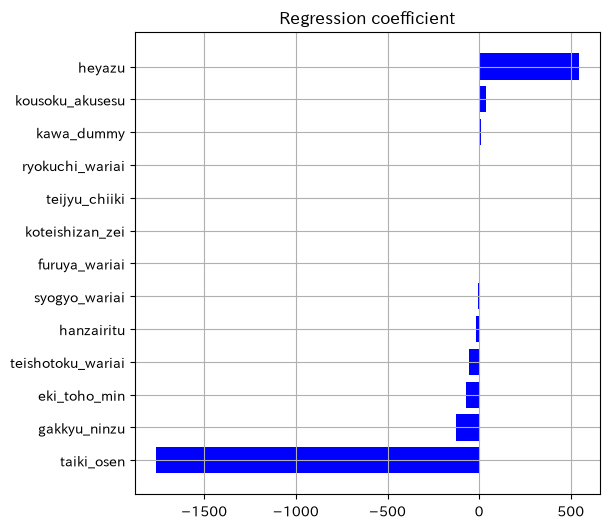

In [26]:
# 回帰係数の可視化
fig, ax = plt.subplots(figsize=(6,6))

imp_coef = coef.sort_values()

ax.barh(imp_coef.index,
        imp_coef,
        color ='blue')

ax.grid()
plt.title('Regression coefficient') 

plt.show() 

### ③　モデルの評価：精度の計算
モデルの汎化性能を評価するために、決定係数（R²スコア）を用いて訓練データとテストデータのスコアを比較します。

**過学習**: モデルが訓練データに過度に適合し、新しいデータに対しては性能が低下する現象です。訓練データのR²スコアが高く、テストデータのR²スコアが低い場合、過学習が疑われます。  
**汎化性能**: モデルが未知のデータに対しても高い予測精度を示す能力です。訓練データとテストデータのR²スコアが近い場合、モデルは汎化性能が高いと考えられます。  

### 訓練データ

In [27]:
#予測値
y_pred_train = model.predict(X_train)

In [28]:
# 訓練データの精度
r2_score = model.score(X_train, y_train)
print('訓練データ決定係数:{:.3f}'.format(r2_score))

訓練データ決定係数:0.776


### テストデータ

In [29]:
#テストデータの予測値
y_pred_test = model.predict(X_test)

In [30]:
# テストデータの精度
r2_score = model.score(X_test, y_test)
print('テストデータ決定係数:{:.3f}'.format(r2_score))

テストデータ決定係数:0.764


### ④　観測値-予測値プロット
機械学習モデルの予測結果と実際の観測値を散布図で可視化したグラフです。このプロットは、モデルの予測精度を評価し、予測誤差の傾向を把握する上で非常に有効です。

**理想的なプロット**: 予測値と観測値がほぼ一致する場合、データ点が対角線上に近接して分布します。これは、モデルがデータの傾向を正しく捉えていることを示します。  
**誤差の傾向**: データ点が対角線から大きく外れている場合、モデルの予測に誤差が含まれていることを示します。また、誤差が特定の範囲で偏っている場合、モデルに改善の余地があることを示唆します。  

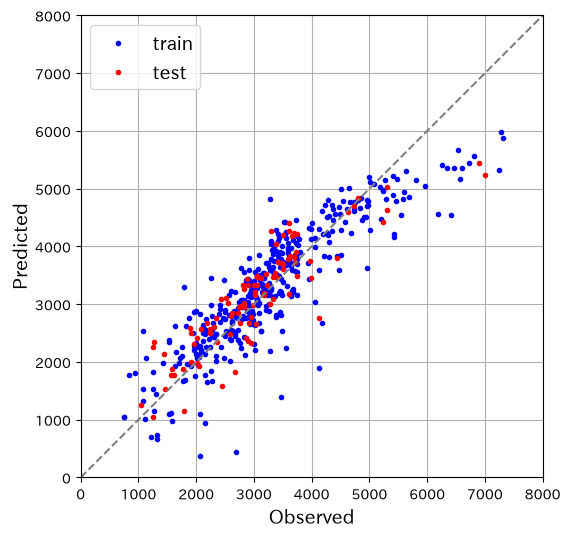

In [35]:
fig, ax = plt.subplots(figsize=(6,6))

#データのプロット
ax.plot(y_train, y_pred_train, '.', c = 'blue', label ='train')
ax.plot(y_test, y_pred_test, '.', c = 'red', label ='test')

# 対角線のプロット
ax.plot([0, 8000], [0, 8000], 
        linestyle='--', 
        color ='gray')  

#グラフの修飾
ax.axis('square')
ax.set_xlabel('Observed',fontsize = 14)
ax.set_ylabel('Predicted',fontsize = 14)

ax.set_xlim(0,8000)
ax.set_ylim(0,8000)
ax.legend(fontsize = 14)
ax.grid()

plt.show()

## 2.Lasso回帰

Lasso回帰は、線形回帰モデルにL1正則化項を追加することで、特徴選択と過学習防止という二つの効果を実現する手法です。

**【1】特徴選択**  
L1正則化項は、モデルの複雑さを抑える働きがあり、多くの場合、一部の回帰係数を厳密に0にします。これにより、目的変数にほとんど影響を与えない無関係な特徴量を自動的にモデルから除外することができます。この特徴選択機能は、高次元のデータにおいて、モデルの解釈性を高め、過学習を防ぐ上で非常に有効です。

**【2】過学習防止**  
L1正則化は、モデルの複雑さを制限することで、過学習を抑制します。過学習とは、モデルが訓練データに過度に適合しすぎてしまい、新しいデータに対しては予測精度が低下する現象です。Lasso回帰は、この過学習問題に対処し、モデルの汎化性能を向上させることができます。  


Lasso回帰は、特徴量が多く、モデルの解釈性や汎化性能を重視する場面で特に有効な手法です。特徴選択と過学習防止という二つの効果を同時に実現できるため、様々な分野で活用されています。

### ①　モデル構築
Lasso回帰は、L1正則化の効果が**特徴量のスケール**に依存します。各特徴量の単位やスケールが異なるため、標準化（StandardScaler）を行わないと、スケールが大きい特徴量だけが正則化の影響を受けにくくなり、係数がゼロになる変数の選択が意図しない結果になる可能性があります。

そこで、`Pipeline` を使って標準化とLasso回帰を一体で扱います。`Pipeline` は複数の処理ステップを順番に実行する仕組みであり、`fit()` や `predict()` を呼び出すだけで、標準化とモデル学習がまとめて実行されます。

In [36]:
# Lasso回帰モデル（StandardScalerで標準化してからLassoを適用）
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

#予測器の作成（Pipeline: 標準化 → Lasso）
model = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso())
])
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('lasso', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['hanzairitu','teijyu_chiiki','syogyo_wariai',...,'gakkyu_ninzu', 'ryokuchi_wariai','teishotoku_wariai']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


### ②　特徴量の評価（重要度）
Lasso回帰では、正則化パラメータ `alpha`（デフォルト：1.0）の強さに応じて、一部の説明変数の係数が厳密に0になります。`alpha` が大きいほど正則化が強くなり、0になる変数が増えます。以下のセルで実際に係数を確認してみましょう。

In [37]:
# Pipelineの中のLassoステップから係数と切片を取り出す
lasso_step = model.named_steps['lasso']
print('係数：', lasso_step.coef_)
print('切片：', lasso_step.intercept_)

係数： [-142.69899134  108.13577776  -47.86717092    2.14502713 -198.88763406
  365.75430921  -83.36672119 -376.78588103  305.17149323 -315.12482589
 -271.72117254  110.71626067 -405.69250501]
切片： 3304.3239795918366


In [38]:
coef = pd.Series(model.named_steps['lasso'].coef_, index=X.columns)
coef

hanzairitu          -142.698991
teijyu_chiiki        108.135778
syogyo_wariai        -47.867171
kawa_dummy             2.145027
taiki_osen          -198.887634
heyazu               365.754309
furuya_wariai        -83.366721
eki_toho_min        -376.785881
kousoku_akusesu      305.171493
koteishizan_zei     -315.124826
gakkyu_ninzu        -271.721173
ryokuchi_wariai      110.716261
teishotoku_wariai   -405.692505
dtype: float64

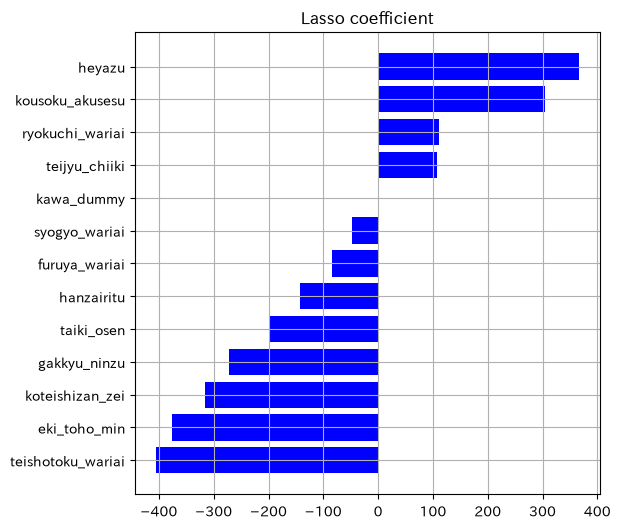

In [39]:
# 回帰係数の可視化
fig, ax = plt.subplots(figsize=(6,6))

imp_coef = coef.sort_values()

ax.barh(imp_coef.index,
        imp_coef,
        color ='blue')

ax.grid()
plt.title('Lasso coefficient') 

plt.show() 

### ③　モデルの評価：精度の計算
### 訓練データ

In [40]:
#予測値
y_pred_train = model.predict(X_train)

In [41]:
# 訓練データの精度
r2_score = model.score(X_train, y_train)
print('訓練データ決定係数:{:.3f}'.format(r2_score))

訓練データ決定係数:0.776


### テストデータ

In [42]:
#テストデータの予測値
y_pred_test = model.predict(X_test)

In [43]:
# テストデータの精度
r2_score = model.score(X_test, y_test)
print('テストデータ決定係数:{:.3f}'.format(r2_score))

テストデータ決定係数:0.764


### ④　観測値-予測値プロット

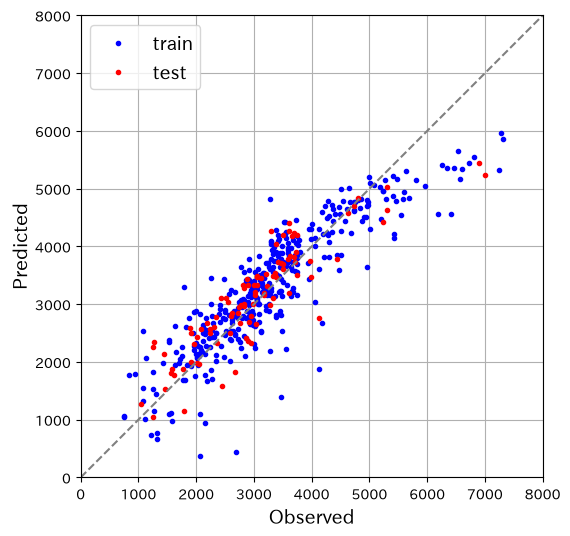

In [45]:
fig, ax = plt.subplots(figsize=(6,6))

#データのプロット
ax.plot(y_train, y_pred_train, '.', c = 'blue', label ='train')
ax.plot(y_test, y_pred_test, '.', c = 'red', label ='test')

# 対角線のプロット
ax.plot([0, 8000], [0, 8000], 
        linestyle='--', 
        color ='gray')  

#グラフの修飾
ax.axis('square')
ax.set_xlabel('Observed',fontsize = 14)
ax.set_ylabel('Predicted',fontsize = 14)

ax.set_xlim(0,8000)
ax.set_ylim(0,8000)
ax.legend(fontsize = 14)
ax.grid()

plt.show()

## 3. ランダムフォレスト

ランダムフォレストは、複数の決定木をランダムに組み合わせることで、高い予測精度と安定性を両立させたアンサンブル学習モデルです。主な特徴は以下の通りです。

**【1】アンサンブル学習による高精度化と過学習防止**  
複数の決定木を組み合わせることで、単一の決定木よりもより複雑なパターンを学習し、予測精度を高めることができます。また、各決定木は異なる特徴量を重視するため、特定の特徴量に過度に依存してしまうことを防ぎ、過学習のリスクを低減します。

**【2】特徴量の重要度評価**  
ランダムフォレストは、各特徴量が予測にどれだけ貢献しているかを定量的に評価する機能を持っています。この機能を活用することで、重要な特徴量を特定し、モデルの解釈性を高めることができます。  

ランダムフォレストは、高い予測精度と解釈性の両方を兼ね備えた強力な機械学習モデルです。様々な分野で活用されており、特に特徴量が多く、複雑なデータに対して有効です。

### ①　モデル構築
`RandomForestRegressor()` は、Scikit-learnにおけるランダムフォレスト回帰のクラスです。`RandomForestRegressor(n_estimators=100)` で、100本の決定木を使用するランダムフォレスト回帰モデルを作成しています。なお、`n_estimators` は、ランダムフォレストに含まれる決定木の数を指定するパラメータです。デフォルト値は100であり、木の数が多いほど予測が安定しますが、計算コストも増加します。

In [46]:
#ランダムフォレスト回帰
from sklearn.ensemble import RandomForestRegressor

#予測器の作成（n_estimators=100: デフォルト値、安定した精度のために100本の決定木を使用）
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

### ②　特徴量の評価（重要度）

In [47]:
coef = pd.Series(model.feature_importances_, index = X.columns)
coef

hanzairitu           0.052004
teijyu_chiiki        0.001512
syogyo_wariai        0.010249
kawa_dummy           0.001336
taiki_osen           0.020571
heyazu               0.464437
furuya_wariai        0.016601
eki_toho_min         0.022572
kousoku_akusesu      0.004832
koteishizan_zei      0.015365
gakkyu_ninzu         0.025057
ryokuchi_wariai      0.015772
teishotoku_wariai    0.349692
dtype: float64

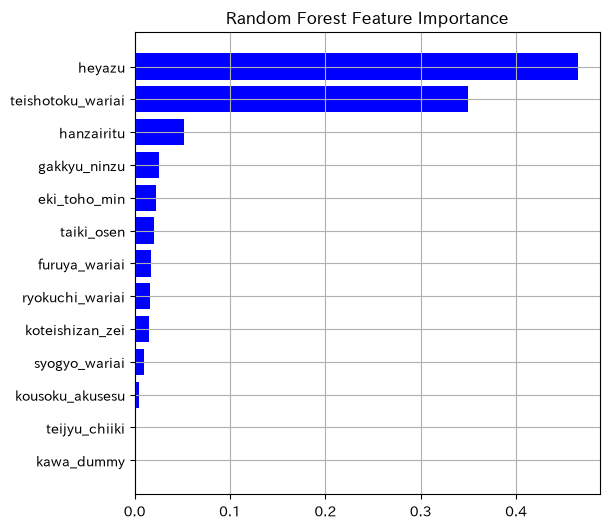

In [48]:
# 回帰係数の可視化
fig, ax = plt.subplots(figsize=(6,6))

imp_coef = coef.sort_values()

ax.barh(imp_coef.index,
        imp_coef,
        color ='blue')

ax.grid()
plt.title('Random Forest Feature Importance') 
plt.show()

### ③　モデルの評価：精度の計算
### 訓練データ

In [49]:
#予測値
y_pred_train = model.predict(X_train)

In [50]:
# 訓練データの精度
r2_score = model.score(X_train, y_train)
print('訓練データ決定係数:{:.3f}'.format(r2_score))

訓練データ決定係数:0.980


### テストデータ

In [51]:
#テストデータの予測値
y_pred_test = model.predict(X_test)

In [52]:
# テストデータの精度
r2_score = model.score(X_test, y_test)
print('テストデータ決定係数:{:.3f}'.format(r2_score))

テストデータ決定係数:0.885


### ④　観測値-予測値プロット

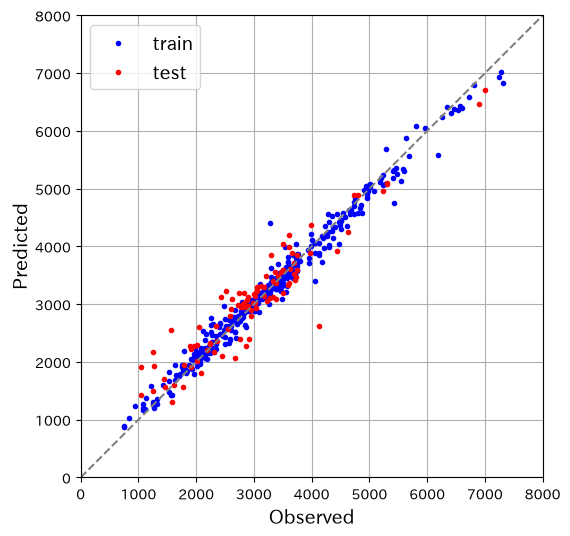

In [54]:
fig, ax = plt.subplots(figsize=(6,6))

#データのプロット
ax.plot(y_train, y_pred_train, '.', c = 'blue', label ='train')
ax.plot(y_test, y_pred_test, '.', c = 'red', label ='test')

# 対角線のプロット
ax.plot([0, 8000], [0, 8000], 
        linestyle='--', 
        color ='gray')  

#グラフの修飾
ax.axis('square')
ax.set_xlabel('Observed',fontsize = 14)
ax.set_ylabel('Predicted',fontsize = 14)

ax.set_xlim(0,8000)
ax.set_ylim(0,8000)
ax.legend(fontsize = 14)
ax.grid()

plt.show()

## Closing：おわりに


さらに機械学習モデルの精度をあげるために、**k-foldクロスバリデーション**や**ハイパーパラメータ調整**を行います。

**k-foldクロスバリデーション（k-fold cross-validation）**  

機械学習モデルの性能を評価するための手法です。通常、データセットをトレーニングセットとテストセットに分割してモデルを評価しますが、クロスバリデーションでは、データセットを複数の部分集合に分割し、それぞれをトレーニングセットとテストセットとして使用します。

具体的な手順は以下の通りです。

1. データセットをk個の部分集合（フォールド）に分割します。通常、kは5または10がよく使用されます。

1. k個の部分集合のうちの1つをテストセットとし、残りのk-1個の部分集合をトレーニングセットとします。

1. モデルをトレーニングセットで学習させ、テストセットで評価します。

1. ステップ2-3をk回繰り返し、k個のモデルを作成し、評価します。

1. k回の評価結果を平均化し、モデルの性能を推定します。

クロスバリデーションは、モデルの性能を正確に評価するために使用されます。各フォールドがテストセットとして使用されるため、全てのデータがモデルの評価に使用されます。これにより、モデルの性能評価がより信頼性の高い結果を提供します。また、データの分割方法による結果のバイアスを軽減する効果もあります。

クロスバリデーションは、ハイパーパラメータのチューニングや異なるモデルの比較など、機械学習のさまざまなタスクで広く使用されます。

**ハイパーパラメータ（hyperparameter）**  

機械学習モデルのハイパーパラメータは、モデルの振る舞いやパフォーマンスに影響を与える設定値です。ハイパーパラメータの適切な調整は、モデルの性能を最適化するために非常に重要です。ハイパーパラメータ調整の一般的な手法には、グリッドサーチ、ランダムサーチ、ベイズ最適化などがあります。scikit-learnでは`GridSearchCV`（グリッドサーチ）および`RandomizedSearchCV`（ランダムサーチ）が提供されています。

* **グリッドサーチ（Grid Search）**：
グリッドサーチでは、事前に指定されたハイパーパラメータ値の組み合わせの中から最適な組み合わせを探索します。具体的には、調整したいハイパーパラメータの範囲を指定し、それらのパラメータの組み合わせをすべて試して最適な組み合わせを見つける手法です。ただし、組み合わせの数が非常に多い場合は計算コストが高くなる可能性があります。

* **ランダムサーチ（Random Search）**：
ランダムサーチでは、ハイパーパラメータの範囲内からランダムに組み合わせを選択し、それらの組み合わせでモデルを評価します。グリッドサーチと比較して効率的な探索が可能であり、特定の範囲内でのハイパーパラメータの重要度を把握するのに役立ちます。

* **ベイズ最適化（Bayesian Optimization）**：
ベイズ最適化は、事前の知識を利用して最適なハイパーパラメータを探索する手法です。モデルの評価結果を利用して、パラメータ空間内で最適な探索を行います。ベイズ最適化は、少ない評価回数で最適なハイパーパラメータを見つけることができる場合があります。

これらの手法は、ハイパーパラメータの探索空間と目的関数の特性に合わせて選択する必要があります。また、クロスバリデーションなどを使用して、ハイパーパラメータの選択によるモデルの性能を適切に評価することも重要です。